### **📊 E-Commerce Sales Analytics Project**

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jatinkhandelwal112/indian-e-commerce-sales-analytics-dataset")

print("Path to dataset files:", path)

100%|██████████| 10.5M/10.5M [00:00<00:00, 129MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jatinkhandelwal112/indian-e-commerce-sales-analytics-dataset/versions/1


In [ ]:
df = pd.read_csv(f'{path}/customers.csv')
df.head()

,Customer_ID,Customer_Name,Gender,Age,Age_Group,Date_of_Birth,Email,Phone,City,State,Pincode,Registration_Date,Customer_Tier,Total_Orders,Total_Spent
0,CUST00000001,Akash Agarwal,male,48,46-55,1977-01-13,akashagarwal@gmail.com,+91-9625152011,Patiala,Punjab,122521,2024-01-28,Gold,5,40098.48
1,CUST00000002,Farhan Rahman,male,73,65+,1952-01-20,farhanrahman@gmail.com,+91-8593009465,Durgapur,West Bengal,226518,2023-08-25,Platinum,8,63676.24
2,CUST00000003,Suresh Kumar,male,31,26-35,1994-01-09,sureshkumar755@gmail.com,+91-7935884774,Gurugram,Haryana,520400,2023-08-30,Silver,0,0.00
3,CUST00000004,Aditya Pandey,male,41,36-45,1984-01-12,adityapandey@outlook.com,+91-9015046072,Kolkata,West Bengal,735356,2024-03-11,Platinum,5,288324.84
4,CUST00000005,Hina Khan,female,53,46-55,1972-01-15,hinakhan433@gmail.com,+91-8813094271,Noida,UP,985141,2024-04-19,Platinum,4,69265.75


In [ ]:
print(df.shape)

(40000, 15)


In [ ]:
print(df.columns.tolist())

['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'Date_of_Birth', 'Email', 'Phone', 'City', 'State', 'Pincode', 'Registration_Date', 'Customer_Tier', 'Total_Orders', 'Total_Spent']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 26250 to 21646
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer_ID        40000 non-null  object        
 1   Customer_Name      40000 non-null  object        
 2   Gender             40000 non-null  object        
 3   Age                40000 non-null  int64         
 4   Age_Group          40000 non-null  object        
 5   Date_of_Birth      40000 non-null  datetime64[ns]
 6   Email              40000 non-null  object        
 7   Phone              40000 non-null  object        
 8   City               40000 non-null  object        
 9   State              40000 non-null  object        
 10  Pincode            40000 non-null  int64         
 11  Registration_Date  40000 non-null  datetime64[ns]
 12  Customer_Tier      40000 non-null  object        
 13  Total_Orders       40000 non-null  int64         
 14  Total_S

In [ ]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,Age_Group,Date_of_Birth,Email,Phone,City,State,Pincode,Registration_Date,Customer_Tier,Total_Orders,Total_Spent
26250,CUST00026251,Rahul Singh,male,22,18-25,2003-01-07,rahulsingh891@gmail.com,+91-9650568277,Howrah,West Bengal,296390,2023-06-01,Platinum,4,190864.97
12668,CUST00012669,Farah Malik,female,28,26-35,1997-01-08,farahmalik772@outlook.com,+91-8761609867,Pune,Maharashtra,825180,2023-06-01,Platinum,2,95544.58
6060,CUST00006061,Farah Ahmed,female,32,26-35,1993-01-09,farahahmed@outlook.com,+91-7242179819,Howrah,West Bengal,713784,2023-06-01,Silver,1,15962.12
35717,CUST00035718,Sana Malik,female,25,18-25,2000-01-08,sanamalik222@outlook.com,+91-9514950483,Durgapur,West Bengal,237089,2023-06-01,Gold,2,23674.00
7149,CUST00007150,Preeti Sharma,female,23,18-25,2002-01-07,preetisharma936@outlook.com,+91-9713862078,Nagpur,Maharashtra,102503,2023-06-01,Platinum,1,91261.86


In [ ]:
df.tail()

,Customer_ID,Customer_Name,Gender,Age,Age_Group,Date_of_Birth,Email,Phone,City,State,Pincode,Registration_Date,Customer_Tier,Total_Orders,Total_Spent
28449,CUST00028450,Vikas Nair,male,21,18-25,2004-01-07,vikasnair@yahoo.com,+91-8642311371,Jalandhar,Punjab,190907,2024-05-31,Platinum,3,104159.57
19272,CUST00019273,Swati Gupta,female,21,18-25,2004-01-07,swatigupta238@gmail.com,+91-8454318920,Madurai,Tamil Nadu,765788,2024-05-31,Platinum,9,160316.66
4050,CUST00004051,Mohammad Ahmed,male,59,56-65,1966-01-16,mohammadahmed113@yahoo.com,+91-9895022469,Mumbai,Maharashtra,894749,2024-05-31,Platinum,8,52954.01
14425,CUST00014426,Riya Iyer,female,25,18-25,2000-01-08,riyaiyer@outlook.com,+91-7751062297,Vadodara,Gujarat,758793,2024-05-31,Platinum,7,194975.90
21646,CUST00021647,Amit Pandey,male,43,36-45,1982-01-12,amitpandey84@yahoo.com,+91-8710607705,Vadodara,Gujarat,984954,2024-05-31,Platinum,4,85368.28


In [ ]:
df.sample(5)

,Customer_ID,Customer_Name,Gender,Age,Age_Group,Date_of_Birth,Email,Phone,City,State,Pincode,Registration_Date,Customer_Tier,Total_Orders,Total_Spent
29449,CUST00029450,Nikhil Shah,male,46,46-55,1979-01-13,nikhilshah@yahoo.com,+91-9609732447,Delhi NCR,Delhi,691032,2023-08-17,Platinum,7,71808.76
15193,CUST00015194,Raj Singh,male,24,18-25,2001-01-07,rajsingh@gmail.com,+91-8274413312,Sohna,Haryana,624304,2024-04-21,Silver,3,14307.24
31142,CUST00031143,Aditya Iyer,male,23,18-25,2002-01-07,adityaiyer210@gmail.com,+91-9035899584,Alwar,Rajasthan,572366,2024-04-03,Platinum,5,80276.72
31039,CUST00031040,Aarav Kumar,male,21,18-25,2004-01-07,aaravkumar358@outlook.com,+91-9681380873,Jodhpur,Rajasthan,880267,2024-04-01,Gold,4,36452.02
20189,CUST00020190,Amandeep Dhillon,male,41,36-45,1984-01-12,amandeepdhillon@yahoo.com,+91-7899065256,Kanpur,UP,681564,2023-12-08,Platinum,3,77436.48


In [ ]:
df.describe()

,Age,Date_of_Birth,Pincode,Registration_Date,Total_Orders,Total_Spent
count,40000.000000,40000,40000.000000,40000,40000.000000,40000.00000
mean,35.306225,1989-09-20 05:28:08.400000128,549135.098375,2023-11-29 20:07:43.680000,5.003475,118539.15886
min,18.000000,1950-01-20 00:00:00,100010.000000,2023-06-01 00:00:00,0.000000,0.00000
25%,26.000000,1982-01-12 00:00:00,325689.750000,2023-08-30 00:00:00,3.000000,37814.14750
50%,33.000000,1992-01-10 00:00:00,547573.500000,2023-11-29 00:00:00,5.000000,90059.66000
75%,43.000000,1999-01-08 00:00:00,773876.000000,2024-02-29 00:00:00,6.000000,169958.41750
max,75.000000,2007-01-06 00:00:00,999986.000000,2024-05-31 00:00:00,17.000000,890131.55000
std,12.581443,NaN,259430.688860,NaN,2.232485,106205.42346


In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
Gender,0
Age,0
Age_Group,0
Date_of_Birth,0
Email,0
Phone,0
City,0
State,0


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print(missing_percentage)

Customer_ID          0.0
Customer_Name        0.0
Gender               0.0
Age                  0.0
Age_Group            0.0
Date_of_Birth        0.0
Email                0.0
Phone                0.0
City                 0.0
State                0.0
Pincode              0.0
Registration_Date    0.0
Customer_Tier        0.0
Total_Orders         0.0
Total_Spent          0.0
dtype: float64


In [ ]:
print("Duplicate rows:",
      df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print(df.dtypes)

Customer_ID                  object
Customer_Name                object
Gender                       object
Age                           int64
Age_Group                    object
Date_of_Birth        datetime64[ns]
Email                        object
Phone                        object
City                         object
State                        object
Pincode                       int64
Registration_Date    datetime64[ns]
Customer_Tier                object
Total_Orders                  int64
Total_Spent                 float64
dtype: object


In [ ]:
df['Registration_Date'] = pd.to_datetime(
    df['Registration_Date'],
    errors='coerce'
)

In [ ]:
df['Date_of_Birth'] = pd.to_datetime(
    df['Date_of_Birth'],
    errors='coerce'
)

In [ ]:
print(df[['Registration_Date',
          'Date_of_Birth']].head())

      Registration_Date Date_of_Birth
26250        2023-06-01    2003-01-07
12668        2023-06-01    1997-01-08
6060         2023-06-01    1993-01-09
35717        2023-06-01    2000-01-08
7149         2023-06-01    2002-01-07


In [ ]:
df['Registration_Year'] = (
    df['Registration_Date'].dt.year
)

In [ ]:
df['Registration_Month'] = (
    df['Registration_Date'].dt.month
)

In [ ]:
df['Month_Name'] = (
    df['Registration_Date'].dt.month_name()
)

In [ ]:
df['Registration_Day'] = (
    df['Registration_Date'].dt.day
)

In [ ]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,Age_Group,Date_of_Birth,Email,Phone,City,State,Pincode,Registration_Date,Customer_Tier,Total_Orders,Total_Spent,Registration_Year,Registration_Month,Month_Name,Registration_Day
26250,CUST00026251,Rahul Singh,male,22,18-25,2003-01-07,rahulsingh891@gmail.com,+91-9650568277,Howrah,West Bengal,296390,2023-06-01,Platinum,4,190864.97,2023,6,June,1
12668,CUST00012669,Farah Malik,female,28,26-35,1997-01-08,farahmalik772@outlook.com,+91-8761609867,Pune,Maharashtra,825180,2023-06-01,Platinum,2,95544.58,2023,6,June,1
6060,CUST00006061,Farah Ahmed,female,32,26-35,1993-01-09,farahahmed@outlook.com,+91-7242179819,Howrah,West Bengal,713784,2023-06-01,Silver,1,15962.12,2023,6,June,1
35717,CUST00035718,Sana Malik,female,25,18-25,2000-01-08,sanamalik222@outlook.com,+91-9514950483,Durgapur,West Bengal,237089,2023-06-01,Gold,2,23674.00,2023,6,June,1
7149,CUST00007150,Preeti Sharma,female,23,18-25,2002-01-07,preetisharma936@outlook.com,+91-9713862078,Nagpur,Maharashtra,102503,2023-06-01,Platinum,1,91261.86,2023,6,June,1


In [ ]:
total_customers = df['Customer_ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 40000


In [ ]:
total_orders = df['Total_Orders'].sum()

print("Total Orders:", total_orders)

Total Orders: 200139


In [ ]:
total_spending = df['Total_Spent'].sum()

print("Total Spending:", total_spending)

Total Spending: 4741566354.41


In [ ]:
average_spending = df['Total_Spent'].mean()

print("Average Spending:", average_spending)

Average Spending: 118539.15886025


In [ ]:
gender_analysis = df.groupby('Gender').agg({
    'Customer_ID': 'count',
    'Total_Orders': 'sum',
    'Total_Spent': 'sum'
})

print(gender_analysis)

        Customer_ID  Total_Orders   Total_Spent
Gender                                         
female        19997        100034  2.381404e+09
male          20003        100105  2.360163e+09


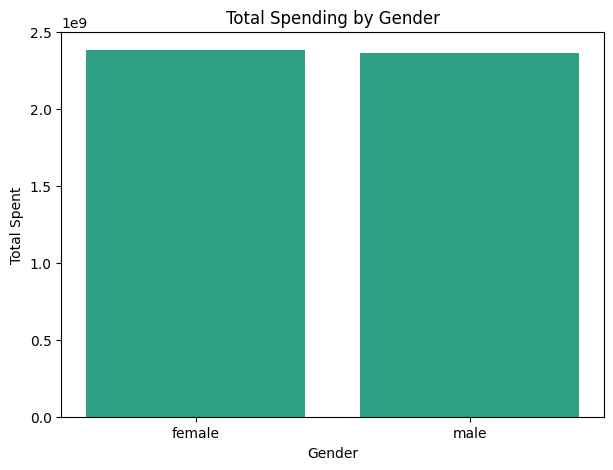

In [ ]:
gender_spending = (
    df.groupby('Gender')['Total_Spent']
    .sum()
)

plt.figure(figsize=(7,5))

plt.bar(
    gender_spending.index,
    gender_spending.values,
    color='#2FA084'
)

plt.title('Total Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Spent')

plt.show()

In [ ]:
city_spending = (
    df.groupby('City')['Total_Spent']
    .sum()
    .sort_values(ascending=False)
)

print(city_spending.head(10))

City
Madurai      1.360117e+08
New Delhi    1.337278e+08
Howrah       1.271472e+08
Dwarka       1.266347e+08
Kanpur       1.264824e+08
Varanasi     1.260877e+08
Amritsar     1.260668e+08
Vadodara     1.250337e+08
Thane        1.247199e+08
Agra         1.246952e+08
Name: Total_Spent, dtype: float64


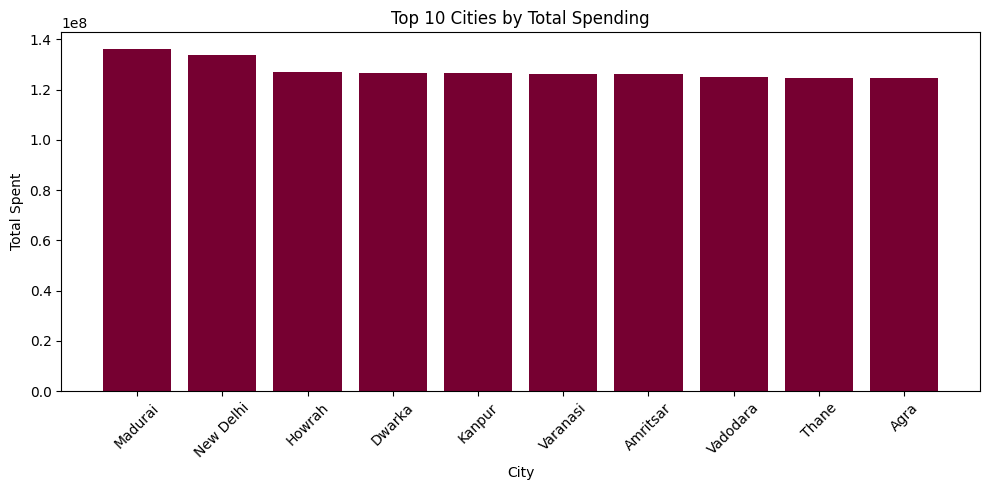

In [ ]:
top_cities = city_spending.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_cities.index,
    top_cities.values,
    color='#760031'

)

plt.title('Top 10 Cities by Total Spending')
plt.xlabel('City')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
state_spending = (
    df.groupby('State')['Total_Spent']
    .sum()
    .sort_values(ascending=False)
)

print(state_spending)

State
UP             6.187059e+08
Rajasthan      6.047446e+08
Haryana        5.977207e+08
Maharashtra    4.847609e+08
Punjab         4.768408e+08
Gujarat        4.760159e+08
Delhi          3.816592e+08
Tamil Nadu     3.759771e+08
West Bengal    3.647380e+08
Karnataka      3.604033e+08
Name: Total_Spent, dtype: float64


In [ ]:
print(state_spending.head(10))

State
UP             6.187059e+08
Rajasthan      6.047446e+08
Haryana        5.977207e+08
Maharashtra    4.847609e+08
Punjab         4.768408e+08
Gujarat        4.760159e+08
Delhi          3.816592e+08
Tamil Nadu     3.759771e+08
West Bengal    3.647380e+08
Karnataka      3.604033e+08
Name: Total_Spent, dtype: float64


In [ ]:
tier_analysis = df.groupby(
    'Customer_Tier'
).agg({
    'Customer_ID': 'count',
    'Total_Orders': 'sum',
    'Total_Spent': 'sum'
})

print(tier_analysis)

               Customer_ID  Total_Orders   Total_Spent
Customer_Tier                                         
Gold                  6692         28674  2.324346e+08
Platinum             27349        153476  4.455365e+09
Silver                5959         17989  5.376676e+07


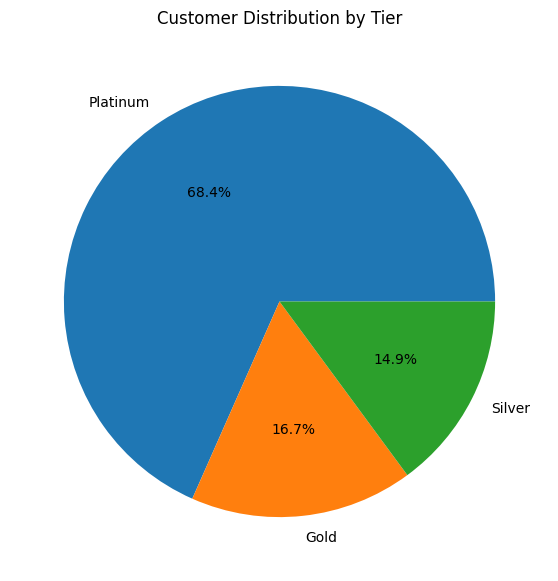

In [ ]:
tier_count = df['Customer_Tier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_count.values,
    labels=tier_count.index,
    autopct='%1.1f%%'

)

plt.title('Customer Distribution by Tier')

plt.show()

In [ ]:
monthly_spending = df.groupby(
    df['Registration_Date'].dt.to_period('M')
)['Total_Spent'].sum()

print(monthly_spending)

Registration_Date
2023-06    3.988219e+08
2023-07    4.063632e+08
2023-08    3.999258e+08
2023-09    3.967975e+08
2023-10    4.031550e+08
2023-11    3.885622e+08
2023-12    3.901997e+08
2024-01    3.917570e+08
2024-02    3.772446e+08
2024-03    3.967496e+08
2024-04    3.982350e+08
2024-05    3.937549e+08
Freq: M, Name: Total_Spent, dtype: float64


In [ ]:
monthly_spending.index = (
    monthly_spending.index.astype(str)
)

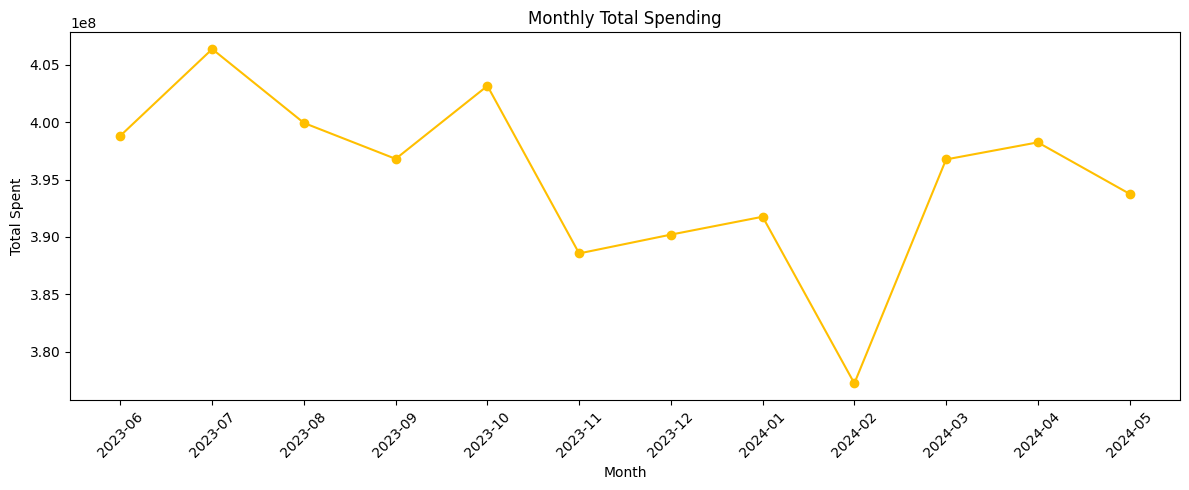

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_spending.index,
    monthly_spending.values,
    marker='o',
    color='#FFBF00'
)

plt.title('Monthly Total Spending')
plt.xlabel('Month')
plt.ylabel('Total Spent')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [ ]:
monthly_orders = df.groupby(
    df['Registration_Date'].dt.to_period('M')
)['Total_Orders'].sum()

monthly_orders.index = (
    monthly_orders.index.astype(str)
)

print(monthly_orders)

Registration_Date
2023-06    16997
2023-07    16829
2023-08    16804
2023-09    16538
2023-10    16589
2023-11    16739
2023-12    16365
2024-01    16898
2024-02    16180
2024-03    16747
2024-04    16731
2024-05    16722
Name: Total_Orders, dtype: int64


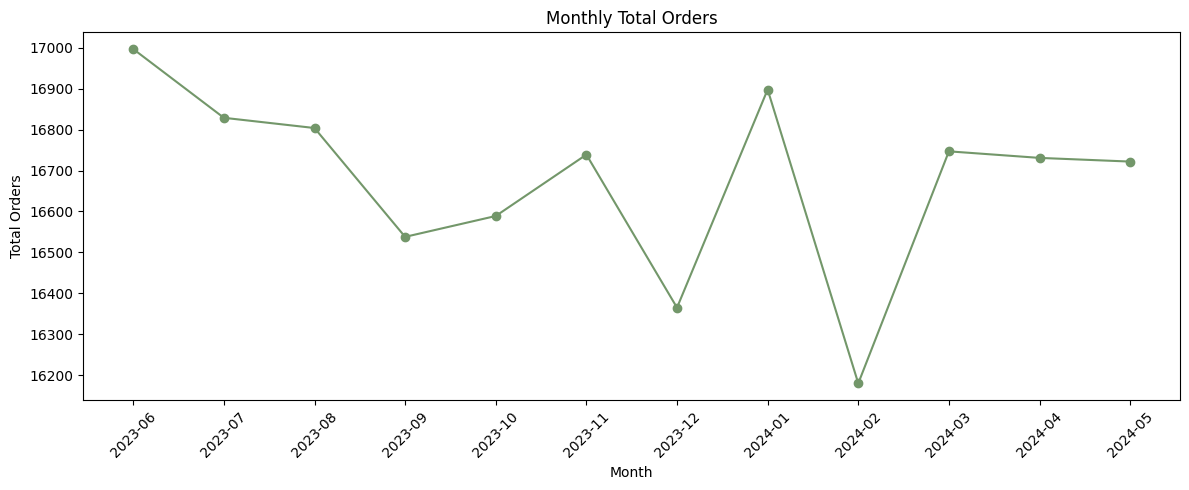

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker='o',
   color='#73976A'
)

plt.title('Monthly Total Orders')
plt.xlabel('Month')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
monthly_spending_df = monthly_spending.to_frame(
    name='Total_Spent'
)

monthly_spending_df['Rolling_Average'] = (
    monthly_spending_df['Total_Spent']
    .rolling(3)
    .mean()
)

print(monthly_spending_df)

                    Total_Spent  Rolling_Average
Registration_Date                               
2023-06            3.988219e+08              NaN
2023-07            4.063632e+08              NaN
2023-08            3.999258e+08     4.017036e+08
2023-09            3.967975e+08     4.010288e+08
2023-10            4.031550e+08     3.999594e+08
2023-11            3.885622e+08     3.961716e+08
2023-12            3.901997e+08     3.939723e+08
2024-01            3.917570e+08     3.901730e+08
2024-02            3.772446e+08     3.864004e+08
2024-03            3.967496e+08     3.885837e+08
2024-04            3.982350e+08     3.907431e+08
2024-05            3.937549e+08     3.962465e+08


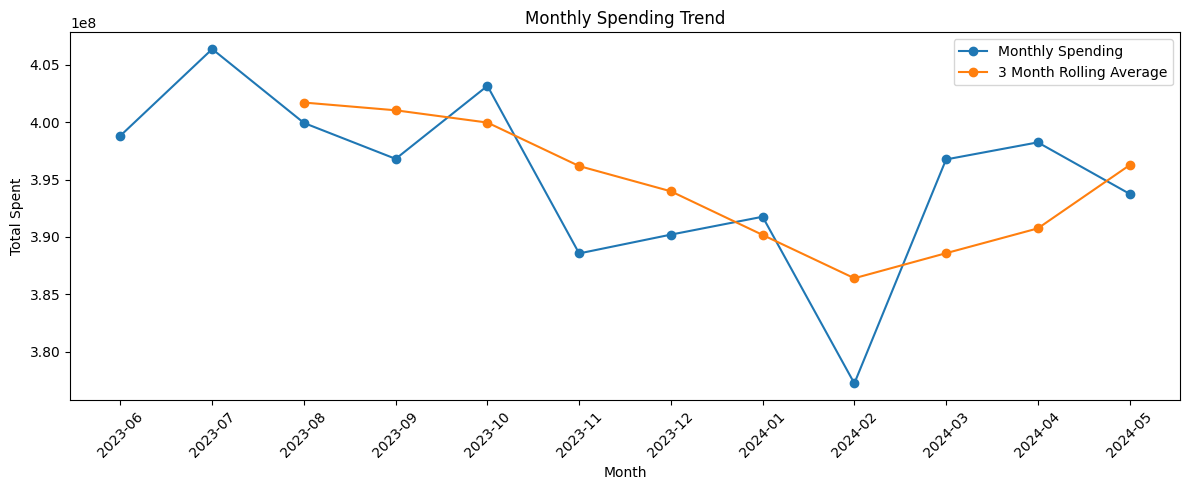

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_spending_df.index,
    monthly_spending_df['Total_Spent'],
    marker='o',
    label='Monthly Spending'
)

plt.plot(
    monthly_spending_df.index,
    monthly_spending_df['Rolling_Average'],
    marker='o',
    label='3 Month Rolling Average'
)

plt.title('Monthly Spending Trend')
plt.xlabel('Month')
plt.ylabel('Total Spent')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
correlation = df[
    ['Age', 'Total_Orders', 'Total_Spent']
].corr()

print(correlation)

                   Age  Total_Orders  Total_Spent
Age           1.000000      0.000798    -0.254177
Total_Orders  0.000798      1.000000     0.493418
Total_Spent  -0.254177      0.493418     1.000000


In [ ]:
import numpy as np

df['Spending_Category'] = np.select(
    [
        df['Total_Spent'] < 10000,
        df['Total_Spent'] < 50000
    ],
    [
        'Low',
        'Medium'
    ],
    default='High'
)

print(df[
    ['Customer_Name',
     'Total_Spent',
     'Spending_Category']
].head(10))

       Customer_Name  Total_Spent Spending_Category
26250    Rahul Singh    190864.97              High
12668    Farah Malik     95544.58              High
6060     Farah Ahmed     15962.12            Medium
35717     Sana Malik     23674.00            Medium
7149   Preeti Sharma     91261.86              High
8980     Swati Joshi      1260.49               Low
35762    Ahmed Mirza     76736.51              High
19487   Gaurav Yadav     75746.57              High
22646     Priya Nair    188744.38              High
17370   Sandeep Kaur     53601.12              High


In [ ]:
top_customers = df.nlargest(
    10,
    'Total_Spent'
)

print(
    top_customers[
        [
            'Customer_ID',
            'Customer_Name',
            'City',
            'Total_Orders',
            'Total_Spent'
        ]
    ]
)

        Customer_ID    Customer_Name       City  Total_Orders  Total_Spent
4599   CUST00004600     Aditya Yadav      Thane             9    890131.55
21065  CUST00021066      Ananya Shah     Kanpur            13    876932.74
9201   CUST00009202      Priya Gupta    Lucknow            12    843527.62
21753  CUST00021754    Ayesha Sheikh  Delhi NCR            12    833959.87
33066  CUST00033067       Rahul Iyer     Nagpur             9    796683.98
3486   CUST00003487      Swati Mehta    Patiala             8    790413.46
10420  CUST00010421    Shreya Tiwari    Chennai             6    781769.62
13491  CUST00013492      Pooja Mehta       Kota            10    781727.73
17167  CUST00017168     Rohan Pandey   Amritsar             8    771239.94
4103   CUST00004104  Nikhil Kulkarni    Patiala             9    753656.40



# 📊Questions & Answers
1.How many total customers are there?

2.How many total orders are there?

3.What is the total spending?

4.What is the average customer spending?

5.Which gender spends more?

6.Which city has the highest spending?

7.Which state has the highest spending?

8.Which customer tier generates the highest revenue?

9.Which month has the highest spending?

10.What is the monthly spending trend?

11.Who are the top 10 customers by spending?

12.Is there a relationship between age and spending?

13.How many customers are in the Low, Medium, and High spending categories?

#1.How many total customers are there?

In [ ]:


total_customers = df['Customer_ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 40000


#2.How many total orders are there?

In [ ]:

total_orders = df['Total_Orders'].sum()

print("Total Orders:", total_orders)

Total Orders: 200139


#3.What is the total spending?

In [ ]:

total_spending = df['Total_Spent'].sum()

print("Total Spending:", total_spending)

Total Spending: 4741566354.41


#4.Which gender spends more?

In [ ]:

gender_spending = df.groupby('Gender')['Total_Spent'].sum().sort_values(ascending=False)

print(gender_spending)

Gender
female    2.381404e+09
male      2.360163e+09
Name: Total_Spent, dtype: float64


#5.Which city has the highest spending?

In [ ]:

city_spending = (
    df.groupby('City')['Total_Spent']
    .sum()
    .sort_values(ascending=False)
)

print(city_spending)

City
Madurai       1.360117e+08
New Delhi     1.337278e+08
Howrah        1.271472e+08
Dwarka        1.266347e+08
Kanpur        1.264824e+08
Varanasi      1.260877e+08
Amritsar      1.260668e+08
Vadodara      1.250337e+08
Thane         1.247199e+08
Agra          1.246952e+08
Chennai       1.244127e+08
Alwar         1.241971e+08
Surat         1.241513e+08
Jodhpur       1.241302e+08
Mangalore     1.229540e+08
Jaipur        1.229173e+08
Kolkata       1.226252e+08
Patiala       1.225106e+08
Nagpur        1.223482e+08
Palwal        1.223243e+08
Noida         1.213279e+08
Delhi NCR     1.212967e+08
Gurugram      1.212640e+08
Mysore        1.211367e+08
Mumbai        1.208321e+08
Lucknow       1.201126e+08
Ludhiana      1.199376e+08
Sohna         1.193446e+08
Kota          1.189565e+08
Panipat       1.186609e+08
Pune          1.168606e+08
Bangalore     1.163126e+08
Faridabad     1.161267e+08
Coimbatore    1.155527e+08
Durgapur      1.149656e+08
Udaipur       1.145434e+08
Ahmedabad     1.145131e

In [ ]:
print(city_spending.head(10))

City
Madurai      1.360117e+08
New Delhi    1.337278e+08
Howrah       1.271472e+08
Dwarka       1.266347e+08
Kanpur       1.264824e+08
Varanasi     1.260877e+08
Amritsar     1.260668e+08
Vadodara     1.250337e+08
Thane        1.247199e+08
Agra         1.246952e+08
Name: Total_Spent, dtype: float64


#6.Which state has the highest spending?

In [ ]:

state_spending = (
    df.groupby('State')['Total_Spent']
    .sum()
    .sort_values(ascending=False)
)

print(state_spending)

State
UP             6.187059e+08
Rajasthan      6.047446e+08
Haryana        5.977207e+08
Maharashtra    4.847609e+08
Punjab         4.768408e+08
Gujarat        4.760159e+08
Delhi          3.816592e+08
Tamil Nadu     3.759771e+08
West Bengal    3.647380e+08
Karnataka      3.604033e+08
Name: Total_Spent, dtype: float64


In [ ]:
print(state_spending.head(10))

State
UP             6.187059e+08
Rajasthan      6.047446e+08
Haryana        5.977207e+08
Maharashtra    4.847609e+08
Punjab         4.768408e+08
Gujarat        4.760159e+08
Delhi          3.816592e+08
Tamil Nadu     3.759771e+08
West Bengal    3.647380e+08
Karnataka      3.604033e+08
Name: Total_Spent, dtype: float64


#7.Which customer tier generates the highest revenue?

In [ ]:

tier_revenue = (
    df.groupby('Customer_Tier')['Total_Spent']
    .sum()
    .sort_values(ascending=False)
)

print(tier_revenue)

Customer_Tier
Platinum    4.455365e+09
Gold        2.324346e+08
Silver      5.376676e+07
Name: Total_Spent, dtype: float64


#8.Which month has the highest spending?

In [ ]:

highest_month = monthly_spending.idxmax()
highest_amount = monthly_spending.max()

print("Highest Spending Month:", highest_month)
print("Total Spending:", highest_amount)

Highest Spending Month: 2023-07
Total Spending: 406363220.97


#9.What is the monthly spending trend?

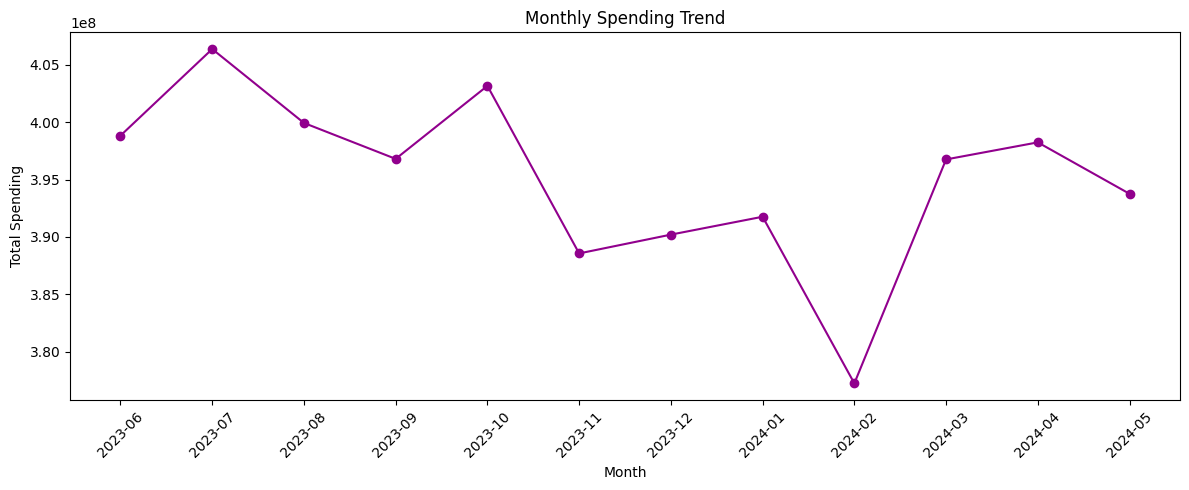

In [ ]:

import matplotlib.pyplot as plt

monthly_spending = (
    df.groupby(df['Registration_Date'].dt.to_period('M'))['Total_Spent']
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_spending.index.astype(str),
    monthly_spending.values,
    marker='o',
    color='#91008D'
)

plt.title('Monthly Spending Trend')
plt.xlabel('Month')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
top_customers = df.nlargest(10, 'Total_Spent')

print(
    top_customers[
        ['Customer_ID', 'Customer_Name', 'Total_Spent']
    ]
)

        Customer_ID    Customer_Name  Total_Spent
4599   CUST00004600     Aditya Yadav    890131.55
21065  CUST00021066      Ananya Shah    876932.74
9201   CUST00009202      Priya Gupta    843527.62
21753  CUST00021754    Ayesha Sheikh    833959.87
33066  CUST00033067       Rahul Iyer    796683.98
3486   CUST00003487      Swati Mehta    790413.46
10420  CUST00010421    Shreya Tiwari    781769.62
13491  CUST00013492      Pooja Mehta    781727.73
17167  CUST00017168     Rohan Pandey    771239.94
4103   CUST00004104  Nikhil Kulkarni    753656.40


#10.Who are the top 10 customers by spending?

In [ ]:

top_10_customers = (
    df.groupby('Customer_ID')['Total_Spent']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Customers by Spending:")
print(top_10_customers)

Top 10 Customers by Spending:
Customer_ID
CUST00004600    890131.55
CUST00021066    876932.74
CUST00009202    843527.62
CUST00021754    833959.87
CUST00033067    796683.98
CUST00003487    790413.46
CUST00010421    781769.62
CUST00013492    781727.73
CUST00017168    771239.94
CUST00004104    753656.40
Name: Total_Spent, dtype: float64


#11.Low / Medium / High Spending Customers?

In [ ]:

import numpy as np

df['Spending_Category'] = np.select(
    [
        df['Total_Spent'] < 10000,
        df['Total_Spent'] < 50000
    ],
    [
        'Low',
        'Medium'
    ],
    default='High'
)

In [ ]:
spending_counts = df['Spending_Category'].value_counts()

print(spending_counts)

Spending_Category
High      27349
Medium     9246
Low        3405
Name: count, dtype: int64


#12.Spending Category Chart?

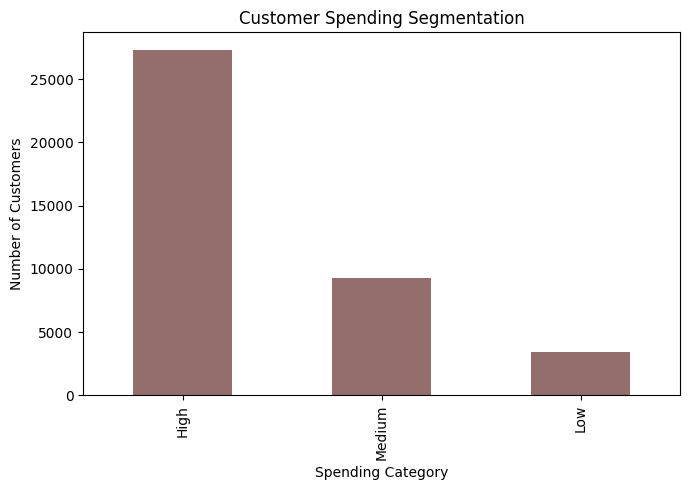

In [ ]:

spending_counts.plot(
    kind='bar',
    figsize=(7,5),
    color='#946D6D'
)

plt.title('Customer Spending Segmentation')
plt.xlabel('Spending Category')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

#13.Is there a relationship between age and spending?

In [ ]:

correlation = df['Age'].corr(df['Total_Spent'])
print("Age-Spending Correlation:", correlation)

Age-Spending Correlation: -0.2541771805754187


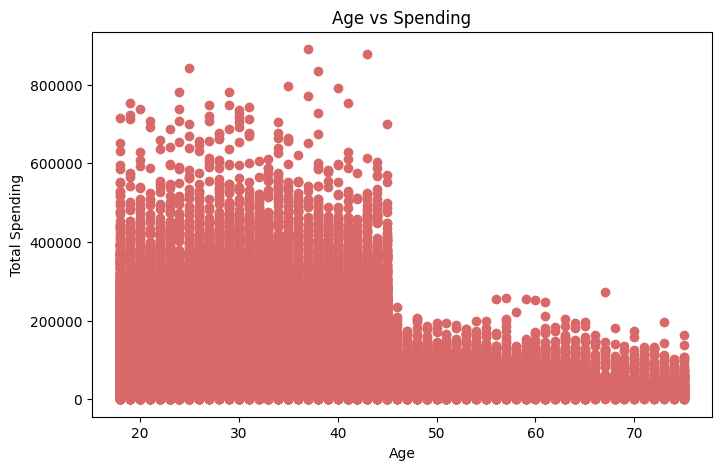

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Age'],
    df['Total_Spent'],
    color='#D96868'
)

plt.title('Age vs Spending')
plt.xlabel('Age')
plt.ylabel('Total Spending')

plt.show()

# **📊 Project Summary**
1.Customer and order analysis

2.Gender, city, and state-wise spending analysis

3.Customer tier revenue analysis

4.Monthly spending trends

5.Top customer identification

6.Age vs. spending correlation

7.Customer spending segmentation into Low, Medium, and High categories

8.Data cleaning, feature engineering, EDA, and visualization1.